# Masked-patch pretraining of SpecFormer, and what its embeddings retrieve

Pretrains `astrospec.models.specformer.SpecFormer` — the spectrum tower of
AstroCLIP ([Parker et al. 2024, MNRAS 531:4990](https://doi.org/10.1093/mnras/stae1450))
— on unlabelled SDSS spectra by reconstructing masked patches, then uses the
resulting token sequence as a representation and searches it for nearest
neighbours.

Nothing here is supervised. The check at the end is whether spectra that land
near each other in embedding space are physically similar, measured against the
one label the survey provides for free: redshift, which the model never sees.

The data path is `utils/sdss.py`, as in `sdss_classification.ipynb`: a local
MultimodalUniverse HDF5 copy if `ASTROSPEC_SDSS_ROOT` is set, otherwise
streaming [`MultimodalUniverse/sdss`](https://huggingface.co/datasets/MultimodalUniverse/sdss)
from the Hub. Both carry `Z`, so this notebook runs either way.

## Install example-only dependencies

Not part of AstroSpec's core install — only needed for this example.

In [1]:
!pip install -q h5py datasets matplotlib

## Imports

In [2]:
import math

import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

import astrospec
from astrospec.data import Patchify
from utils import sdss

torch.manual_seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## Load spectra

16,000 spectra with their pipeline redshifts, resampled onto a common grid and
standardized per spectrum. SpecFormer positions its patches by index rather than
by `wavelength`, so a consistent grid is what makes the position embedding mean
the same thing for every object.

In [3]:
flux, z = sdss.load_spectra(16000, redshift=True)
flux = sdss.standardize(flux)
flux.shape, z.min(), z.max()

((16000, 3841), np.float32(-0.0040198765), np.float32(6.37145))

## Pixels to patches

`Patchify` cuts each spectrum into 20-pixel patches and reports which of them
are padding, so the model can keep padded patches out of attention.

AstroCLIP's tower takes 22 numbers per patch, not 20: the patch standardized by
its own mean and standard deviation, with those two statistics appended. That
keeps a bright and a faint spectrum with the same shape close together, while
leaving the model the amplitude it just divided out.

In [4]:
patchify = Patchify(patch_size=20)
patches, valid = patchify(torch.from_numpy(flux))

def to_tokens(patches):
    mean = patches.mean(-1, keepdim=True)
    std = patches.std(-1, keepdim=True).clamp_min(1e-6)
    return torch.cat([(patches - mean) / std, mean, std], dim=-1)

tokens = to_tokens(patches)
tokens.shape, valid.shape, valid[0].sum().item()

(torch.Size([16000, 193, 22]), torch.Size([16000, 193]), 192)

## Split and batch

The last 1,000 spectra are held out; they are what the retrieval at the end
searches over, and the model is never trained on them.

In [5]:
n_val = 1000
train_tokens, val_tokens = tokens[:-n_val], tokens[-n_val:]
train_valid, val_valid = valid[:-n_val], valid[-n_val:]
val_z = z[-n_val:]

train_loader = DataLoader(
    TensorDataset(train_tokens, train_valid), batch_size=64, shuffle=True
)
len(train_tokens), len(val_tokens)

(15000, 1000)

## The model

The registry defaults are the published configuration, 6 layers of width 768,
about 43M parameters. That is small enough to train here without shrinking it:
one pass over 15,000 spectra takes roughly 45 seconds on an A100, so the run
below is about half an hour. Only `max_len` has to be set, to the number of
patches the spectra were cut into.

In [6]:
model = astrospec.create_model(
    "specformer", input_dim=tokens.shape[-1], max_len=tokens.shape[1]
).to(device)
sum(p.numel() for p in model.parameters())

42711574

## Pretrain by masked reconstruction

A quarter of the real patches are zeroed and the model reconstructs them from
the rest; the loss is taken on the masked positions only, so nothing is gained
by copying the input through. Padded patches are excluded from both the masking
and the loss, and are hidden from attention through the `valid` flag.

The schedule matters at this width. A flat 3e-4 sends the loss back up around
epoch 10 and leaves the encoder in a state whose embeddings are useless for
retrieval, so the peak rate is 1e-4, warmed up over the first 10% of steps and
cosine-decayed after, with gradients clipped at norm 1.

In [7]:
EPOCHS = 45
MASK_RATIO = 0.25
PEAK_LR = 1e-4
optimizer = torch.optim.AdamW(model.parameters(), lr=PEAK_LR, weight_decay=1e-2)

total_steps = EPOCHS * len(train_loader)
warmup_steps = int(0.1 * total_steps)

def learning_rate(step):
    if step < warmup_steps:
        return PEAK_LR * step / warmup_steps
    progress = (step - warmup_steps) / (total_steps - warmup_steps)
    return PEAK_LR * 0.5 * (1 + math.cos(math.pi * progress))

def masked_step(batch_tokens, batch_valid):
    mask = (torch.rand(batch_tokens.shape[:2], device=device) < MASK_RATIO) & batch_valid
    inputs = batch_tokens.masked_fill(mask.unsqueeze(-1), 0.0)
    prediction = model(inputs, valid=batch_valid)
    error = (prediction - batch_tokens).pow(2).mean(-1)
    return (error * mask).sum() / mask.sum().clamp_min(1)

step = 0
for epoch in range(EPOCHS):
    model.train()
    running = 0.0
    for batch_tokens, batch_valid in train_loader:
        for group in optimizer.param_groups:
            group["lr"] = learning_rate(step)
        batch_tokens, batch_valid = batch_tokens.to(device), batch_valid.to(device)
        optimizer.zero_grad()
        loss = masked_step(batch_tokens, batch_valid)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        running += loss.item() * len(batch_tokens)
        step += 1
    print(f"epoch {epoch + 1:2d}  masked-patch MSE {running / len(train_tokens):.4f}")

epoch  1  masked-patch MSE 0.9703


epoch  2  masked-patch MSE 0.8988


epoch  3  masked-patch MSE 0.8894


epoch  4  masked-patch MSE 0.8760


epoch  5  masked-patch MSE 0.8692


...

epoch 41  masked-patch MSE 0.7695


epoch 42  masked-patch MSE 0.7696


epoch 43  masked-patch MSE 0.7693


epoch 44  masked-patch MSE 0.7690


epoch 45  masked-patch MSE 0.7689


## Embed the held-out spectra

`forward_features` returns one token per patch — the representation the
downstream tasks use. Averaging the valid tokens is the cheapest way to get one
vector per spectrum; a trained pooling head does better, and is what the
library's own downstream head is for.

Every spectrum's mean-pooled vector carries the same large common component, so
raw cosine similarities all sit above 0.999 and say nothing. Subtracting the
mean embedding of the set removes that component and leaves scores that can be
read. It changes which neighbour is nearest for only a handful of spectra.

In [8]:
@torch.no_grad()
def embed(batch_tokens, batch_valid):
    model.eval()
    out = []
    for i in range(0, len(batch_tokens), 64):
        t = batch_tokens[i : i + 64].to(device)
        v = batch_valid[i : i + 64].to(device)
        features = model.forward_features(t, valid=v)
        pooled = (features * v.unsqueeze(-1)).sum(1) / v.sum(1, keepdim=True)
        out.append(pooled.cpu())
    return torch.cat(out)

pooled = embed(val_tokens, val_valid)
embeddings = F.normalize(pooled - pooled.mean(0, keepdim=True), dim=-1)
embeddings.shape

torch.Size([1000, 768])

## Nearest neighbours

Cosine similarity between the embeddings of the held-out spectra. The score says
how tight the retrieval is; the redshift columns say whether it found anything
physical, given that redshift was never part of the objective. Random pairs are
the baseline for both.

In [9]:
similarity = embeddings @ embeddings.T
similarity.fill_diagonal_(-1)
best = similarity.max(-1)
neighbour, neighbour_score = best.indices.numpy(), best.values.numpy()

rng = np.random.default_rng(0)
shuffled = rng.permutation(len(val_z))
random_score = (embeddings * embeddings[shuffled]).sum(-1).numpy()

print(f"{'':>17}  {'cosine':>8}  {'median |dz|':>12}  {'|dz| < 0.01':>12}")
for name, score, delta in [
    ("nearest neighbour", neighbour_score, np.abs(val_z - val_z[neighbour])),
    ("random pair", random_score, np.abs(val_z - val_z[shuffled])),
]:
    print(
        f"{name:>17}  {np.median(score):8.3f}  {np.median(delta):12.4f}"
        f"  {(delta < 0.01).mean():11.1%}"
    )

                     cosine   median |dz|   |dz| < 0.01
nearest neighbour     0.753        0.0112        46.7%
      random pair    -0.004        0.0864         7.7%


## A query and its three nearest neighbours

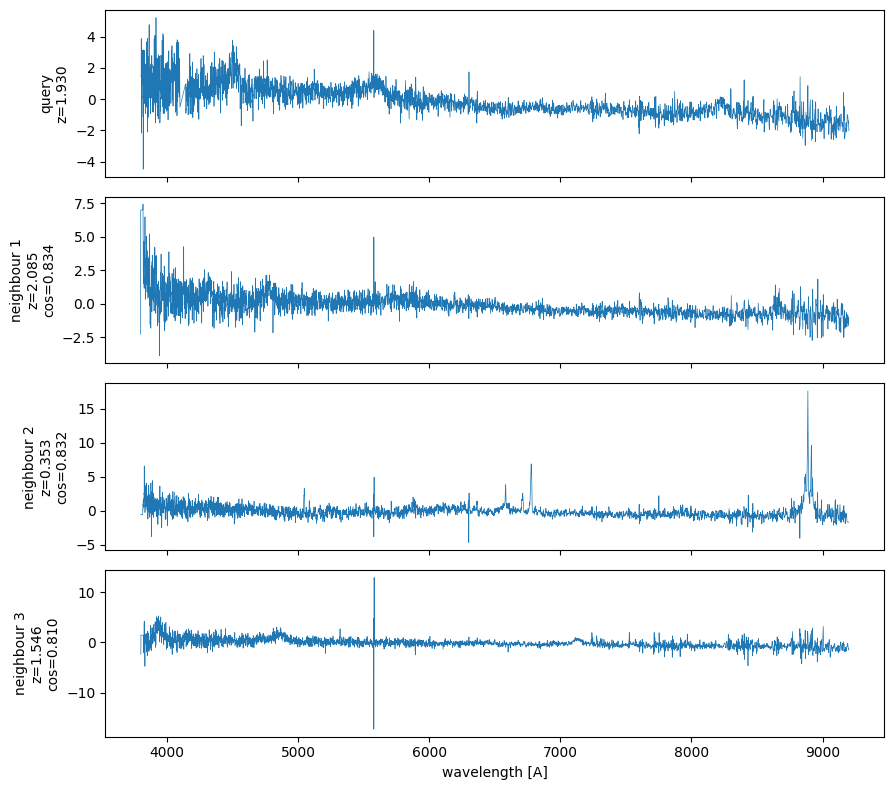

In [10]:
import matplotlib.pyplot as plt

query = int(np.argmax(val_z > 0.3))
top = similarity[query].topk(3)
panels = [(query, "query", None)] + [
    (int(i), f"neighbour {k + 1}", float(s))
    for k, (i, s) in enumerate(zip(top.indices, top.values))
]

fig, axes = plt.subplots(4, 1, figsize=(9, 8), sharex=True)
for ax, (i, title, score) in zip(axes, panels):
    ax.plot(sdss.COMMON_GRID, flux[-n_val:][i], lw=0.5)
    label = f"{title}\nz={val_z[i]:.3f}"
    ax.set_ylabel(label if score is None else f"{label}\ncos={score:.3f}")
axes[-1].set_xlabel("wavelength [A]")
fig.tight_layout()

## Notes

The run is small on purpose: 16,000 spectra and 45 epochs, with mean-pooled
tokens as the read-out. It shows the objective and the retrieval working end to
end on library pieces, `Patchify`, `SpecFormer.forward`, and
`SpecFormer.forward_features`. A trained pooling head does better than the mean,
and is what the library's downstream head is for.

One detail to know before scaling this up: the head here reconstructs patch
values directly, while AstroCLIP's masked-modelling loss compares the model's
projections of the masked and unmasked input.

Reading the two rows: a nearest neighbour is both more similar in embedding
space and far closer in redshift than a random pair, so the embedding groups
spectra by where their lines fall, which is what an index-positioned transformer
can pick up from shape alone. It is not a redshift estimator. For that, attach a
supervised head, or use the template-fitting models in the library.